# Dealing with drift: when and how to retrain

The same drift scenario as in `10`. Each strategy forecasts every day of 2025 with the
model it has at that time. The forecasts are scored against the **true** sales in the
catalog units (kg, count), because orders are placed in these units. The recorded sales
can be wrong (scales, lb).

In [1]:
import altair as alt
import numpy as np
import pandas as pd
from IPython.display import display
from river import drift

import inventory_data as d
from inventory_data import forecast, viz

alt.renderers.enable("png", scale_factor=2)  # static images: GitHub shows them
viz.enable()

In [2]:
PRODUCTS = [101, 102, 103, 104, 105, 106, 110, 117, 123, 127, 128, 132, 143, 146, 151, 154]  # noqa: F841, E501
sales = d.drift_sales().query("product_id in @PRODUCTS")
truth = d.drift_truth().query("product_id in @PRODUCTS")[
    ["date", "store_id", "product_id", "true_sales"]
]
stores = d.drift_stores()
data = forecast.features(sales, stores, d.drift_weather()).merge(
    truth, on=["date", "store_id", "product_id"]
)

kg = data.product_id.isin(d.products().query("unit == 'kg'").id)
lb = kg & data.store_id.isin([7, 8]) & (data.date >= "2025-09-01")
fahrenheit = data.date >= "2025-10-15"
repaired = data.assign(
    quantity=np.where(lb, data.quantity / 2.20462, data.quantity),
    temp_c=np.where(fahrenheit, (data.temp_c - 32) * 5 / 9, data.temp_c),
)

In [3]:
def backtest(data, when="never", window_days=None):
    """Forecast each day of 2025; retrain 'never', 'monthly', or on a drift 'alarm'."""
    model = forecast.train(data[data.date < "2025-01-01"], max_iter=100)
    detector = drift.PageHinkley(min_instances=7, delta=0.02, threshold=0.5, mode="both")
    preds, retrains, last = [], [], pd.Timestamp("2025-01-01")
    for day in pd.date_range("2025-01-01", "2025-12-31"):
        history = data[data.date < day]
        due = (when == "monthly" and day.day == 1 and day > last) or (
            when == "alarm" and detector.drift_detected and (day - last).days >= 14
        )
        if due:
            start = day - pd.Timedelta(days=window_days) if window_days else history.date.min()
            model = forecast.train(history[history.date >= start], max_iter=100)
            retrains.append(day)
            last = day
        today = data[data.date == day]
        today = today.assign(pred=forecast.predict(model, today))
        detector.update(today.quantity.sum() / today.pred.sum())
        preds.append(today)
    return pd.concat(preds), retrains

In [4]:
runs = {
    "static (2024 model)": backtest(data),
    "retrain monthly, all data": backtest(data, "monthly"),
    "retrain monthly, last 90 days": backtest(data, "monthly", window_days=90),
    "retrain on a drift alarm, last 90 days": backtest(data, "alarm", window_days=90),
    "repair the data, retrain monthly (90 days)": backtest(repaired, "monthly", window_days=90),
}

In [5]:
rows = []
for name, (pred, retrains) in runs.items():
    m = pred.assign(month=pred.date.dt.to_period("M").dt.to_timestamp())
    g = (
        m.groupby("month")
        .apply(
            lambda x: pd.Series(
                {"WAPE vs true sales": np.abs(x.pred - x.true_sales).sum() / x.true_sales.sum()}
            ),
            include_groups=False,
        )
        .reset_index()
    )
    rows.append(g.assign(strategy=name, retrains=len(retrains)))
monthly_error = pd.concat(rows)
summary = (
    monthly_error.groupby("strategy", sort=False)
    .agg(
        **{
            "mean WAPE Jan-Aug": ("WAPE vs true sales", lambda s: s.iloc[:8].mean()),
            "mean WAPE Sep-Dec": ("WAPE vs true sales", lambda s: s.iloc[8:].mean()),
            "retrains": ("retrains", "first"),
        }
    )
    .round(3)
)

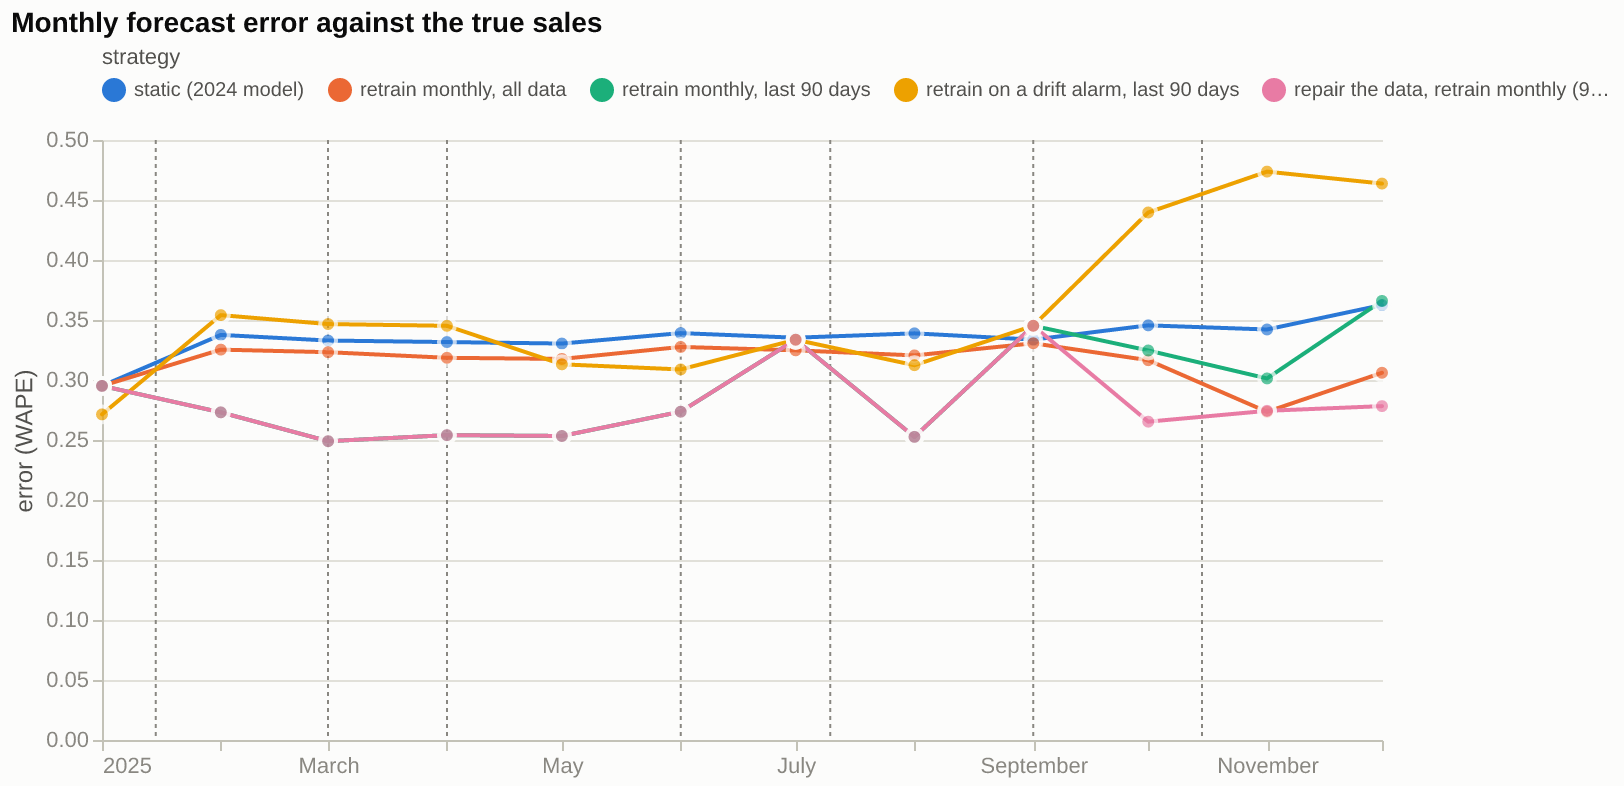

,mean WAPE Jan-Aug,mean WAPE Sep-Dec,retrains
strategy,,,
static (2024 model),0.330,0.346,0
"retrain monthly, all data",0.319,0.307,11
"retrain monthly, last 90 days",0.273,0.334,11
"retrain on a drift alarm, last 90 days",0.323,0.431,8
"repair the data, retrain monthly (90 days)",0.273,0.291,11


In [6]:
ev = d.drift_events().assign(start=lambda e: pd.to_datetime(e.start))
rules = (
    alt.Chart(ev)
    .mark_rule(color="#898781", strokeDash=[2, 2])
    .encode(x="start:T", tooltip=["start", "kind", "event"])
)
base = alt.Chart(monthly_error).encode(
    x=alt.X("month:T", title=None),
    y=alt.Y("WAPE vs true sales:Q", title="error (WAPE)"),
    color=alt.Color("strategy:N", sort=list(summary.index)),
    tooltip=[
        "strategy",
        alt.Tooltip("month:T", format="%b %Y"),
        alt.Tooltip("WAPE vs true sales:Q", format=".3f"),
    ],
)
display(
    (rules + base.mark_line() + base.mark_point()).properties(
        width=640, height=300, title="Monthly forecast error against the true sales"
    )
)
display(summary)

## What to take away

- Without retraining, the model keeps the old concept (no fad diet, no competitor). Regular
  retraining on recent data follows concept drift; a sliding window forgets the old
  concept faster than a model trained on all data.
- **Retraining does not fix schema drift.** After the POS update, the model learns that
  stores 7 and 8 "sell" 2.2 times more (in lb) and would order too much; after the
  weather API change it mixes °F with °C. Compare Sep–Dec: only the strategy that repairs
  the data first stays good. A model on all data suffers less, because the bad months are
  a small part of its training data.
- **An alarm is a reason for a human to look, not for blind retraining.** Here the alarm-
  triggered model retrained on the corrupted lb data and became the worst model.
- A retraining schedule is a trade-off between the cost of training and validation and how
  fast the model follows the world. Monitoring (`monitor.py`) tells humans *when* to look.